In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
# Feature engineering 

df["Age"] = 2026 - df["Year_Birth"]

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_tenuever"] = ( reference_date - df["Dt_Customer"]).dt.days

In [6]:
df["total_kid"] = df["Kidhome"] + df["Teenhome"]

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [7]:
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate" , "2n Cycle" : "Undergraduate" ,
    "Graduation" : "Graduate" ,
    "Master" : "Postgraduate" , "PhD" : "Postgraduate"
})

df["Live_with"] = df["Marital_Status"].replace({
    "Together" : "Married",
    "Divorced" : "Single" , "Widow" : "Single" , "Alone" : "Single" , "Absurd" : "Single" , "YOLO" : "Single"
})

In [8]:
df.head()

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenuever', 'total_kid',
       'Total_spending', 'Live_with'],
      dtype='object')

In [9]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spend = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

columsdrop = cols + spend

df_cleaned = df.drop(columns=columsdrop)

In [10]:
df_cleaned.shape
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_tenuever',
       'total_kid', 'Total_spending', 'Live_with'],
      dtype='object')

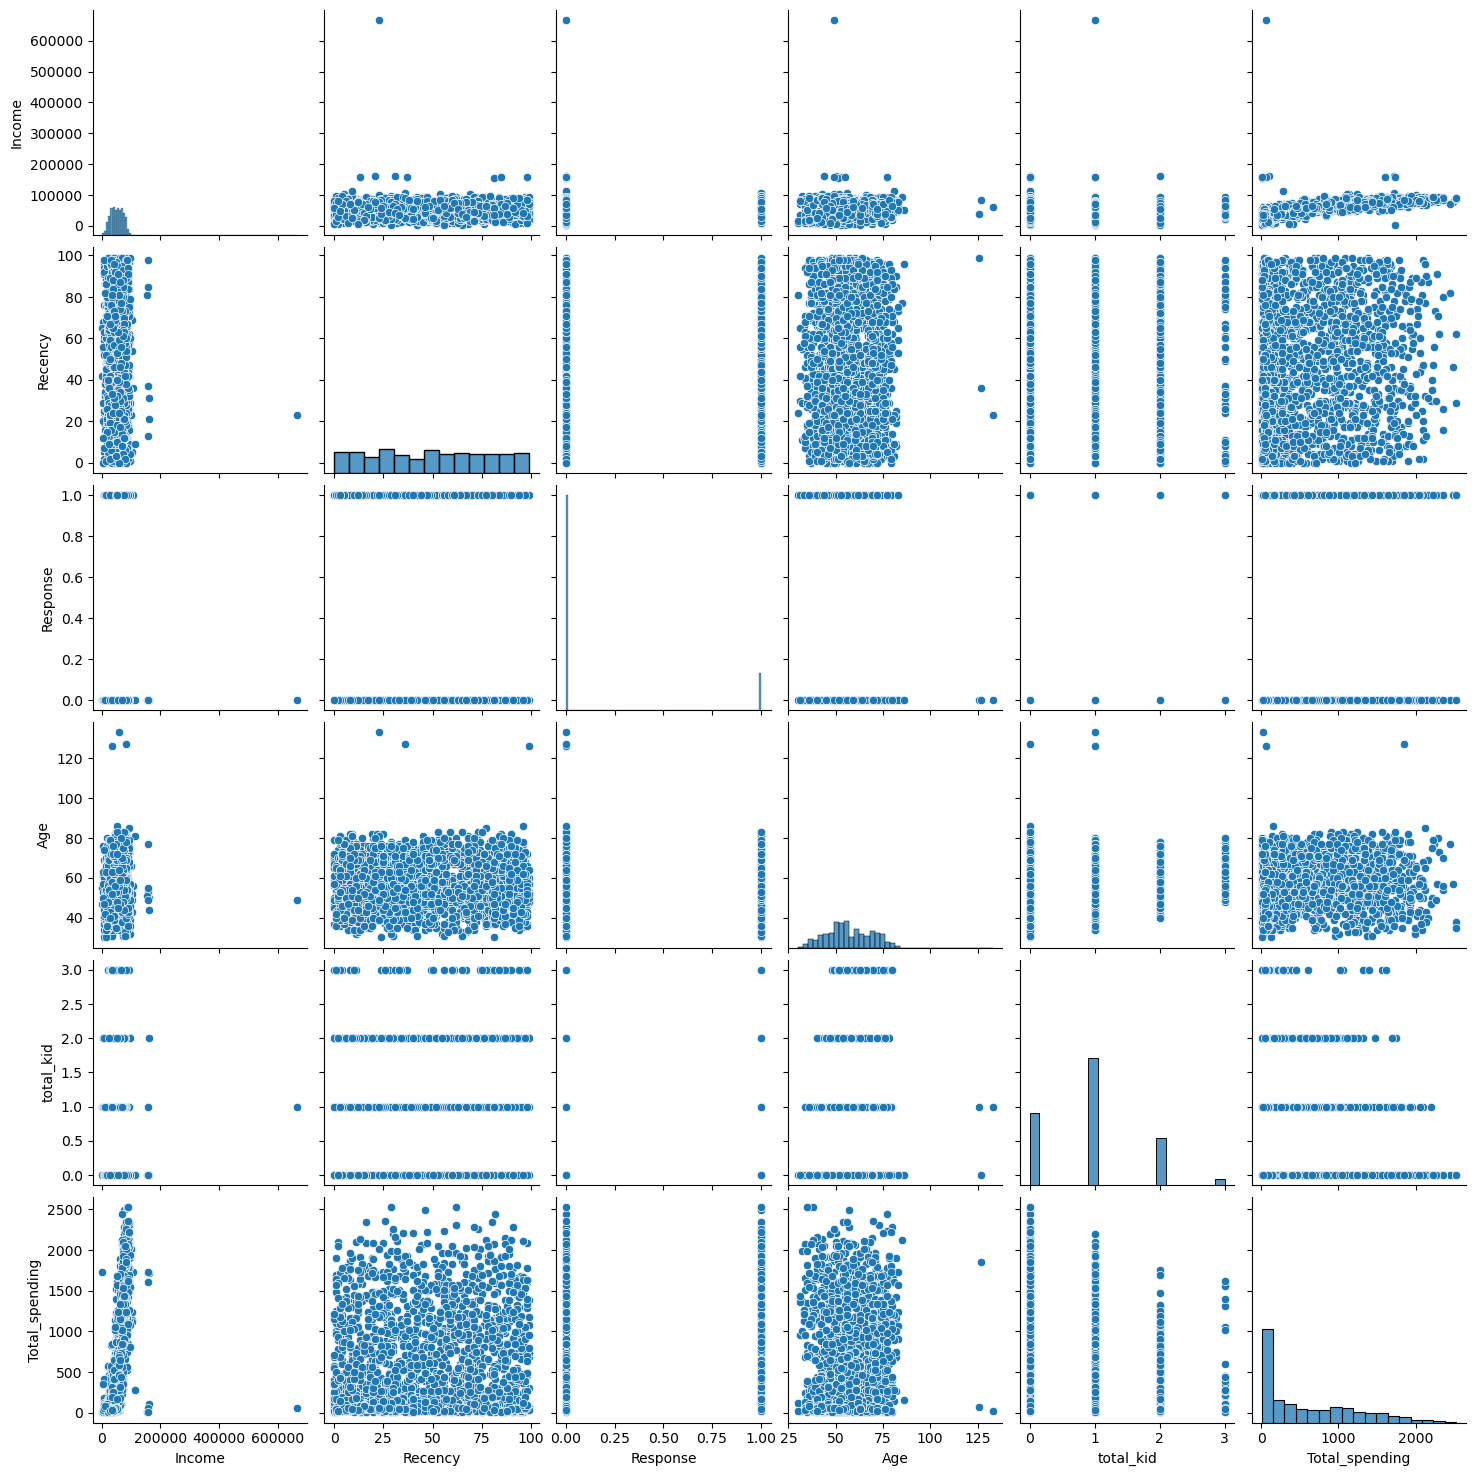

In [11]:
# outlier 

cols = ['Income', 'Recency', 'Response', 'Age','total_kid','Total_spending']

sns.pairplot(df_cleaned[cols])

In [12]:
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600000)]

print("len of data without outlier : ",len(df_cleaned))


len of data without outlier :  2236


<Axes: >

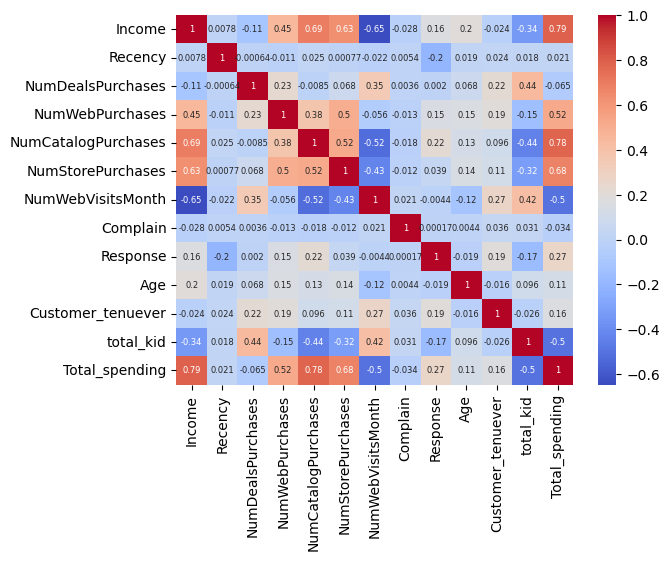

In [13]:
#heatmap

corr = df_cleaned.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size" : 6},
    cmap="coolwarm"
)

In [14]:
# One hot encoding 

from sklearn.preprocessing import OneHotEncoder

colm = ["Education","Live_with"]
ohe = OneHotEncoder()

encod_cl = ohe.fit_transform(df_cleaned[colm])

encode_cl = pd.DataFrame(encod_cl.toarray(), columns=ohe.get_feature_names_out(colm),index=df_cleaned.index)

In [15]:
encode_cl

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Live_with_Married,Live_with_Single
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,1.0,0.0
2236,0.0,1.0,0.0,1.0,0.0
2237,1.0,0.0,0.0,0.0,1.0
2238,0.0,1.0,0.0,1.0,0.0


In [16]:
encode_df = pd.concat([df_cleaned.drop(columns=colm), encode_cl],axis=1)

In [17]:
# scaling the data
X = encode_df

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [18]:
# vizualizing in 3d do pca first

from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, 'pca in 3d')

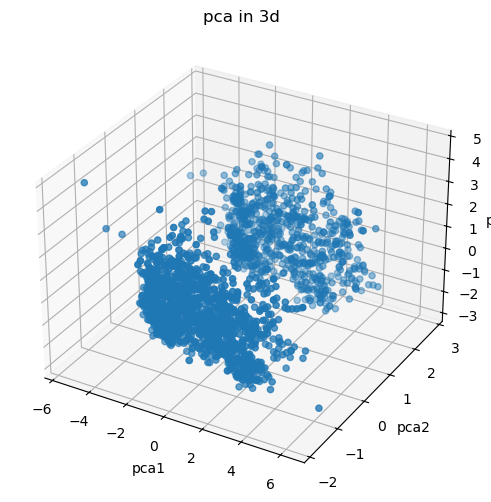

In [19]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2])

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("pca in 3d")




In [20]:
# analyze model 
# k value by elbow method

from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [21]:
from kneed import KneeLocator

knee =  KneeLocator(range(1,11), wcss ,curve = "convex" , direction="decreasing")

best_k_value = knee.elbow 

print("best k value : ",best_k_value)

best k value :  4


Text(0, 0.5, 'wcss')

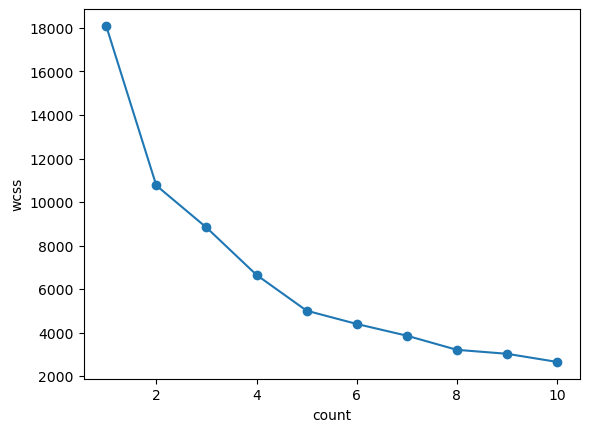

In [22]:
plt.plot(range(1,11), wcss , marker ="o")
plt.xlabel("count")
plt.ylabel("wcss")

In [23]:
#by silhuotte score

from sklearn.metrics import silhouette_score

score = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    lables = kmeans.fit_predict(X_pca)
    scores = silhouette_score(X_pca,lables)
    score.append(scores)

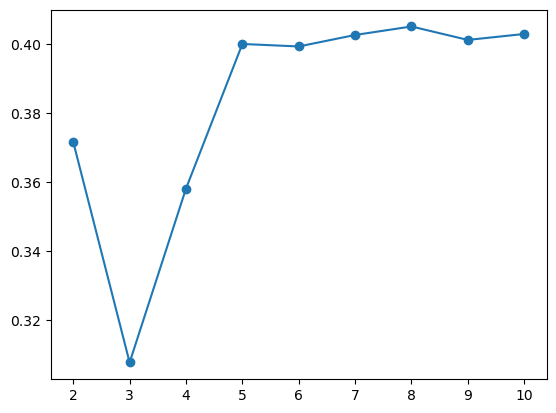

In [24]:
plt.plot(range(2,11),score, marker = "o")

Text(0, 0.5, 'score')

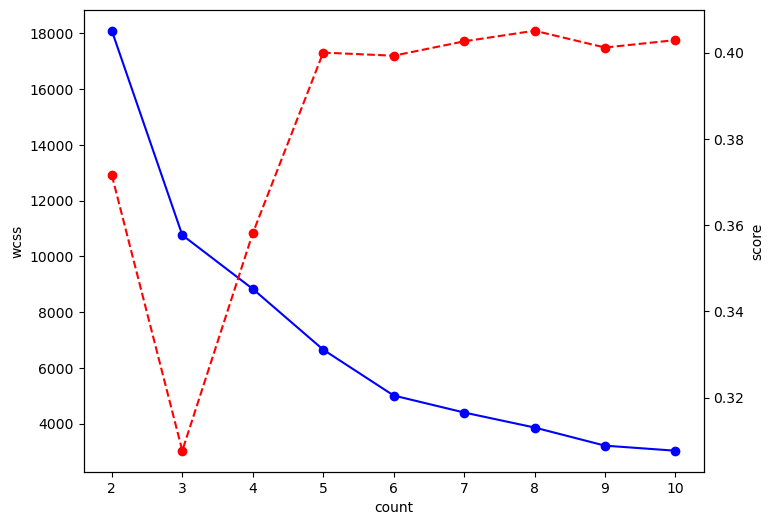

In [25]:

k_range = range(2,11)

fig , ax1  = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)],marker = "o" , c= "blue")
ax1.set_xlabel("count")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, score[:len(k_range)],marker = "o" , c= "red",linestyle = "--")
ax2.set_ylabel("score")


In [26]:

# kmeans model 

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,random_state=42)
labelkmeans = kmeans.fit_predict(X_pca)


Text(0.5, 0.92, 'pca in 3d')

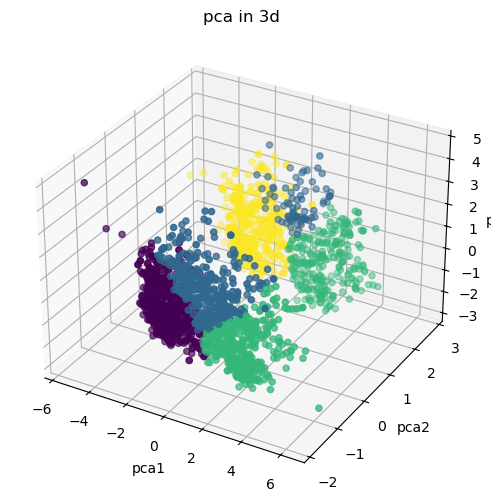

In [27]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2],c= labelkmeans)

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("pca in 3d")

In [28]:
# agglomaritive 

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
label_agg = agg.fit_predict(X_pca)

Text(0.5, 0.92, 'pca in 3d')

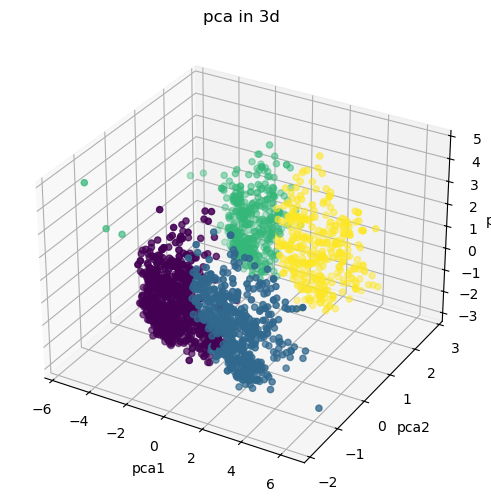

In [29]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2],c= label_agg)

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("pca in 3d")

In [30]:
X["Clusters"] = label_agg


<Axes: xlabel='Clusters', ylabel='count'>

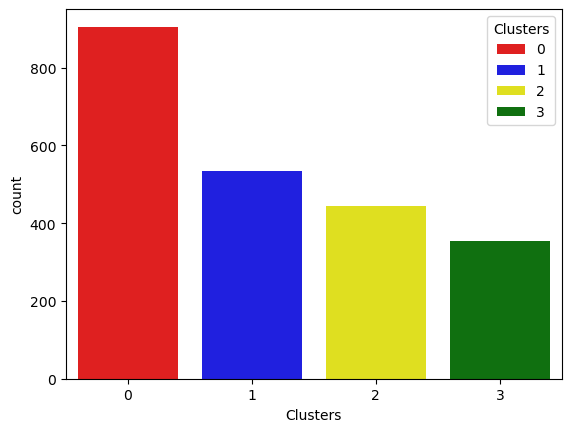

In [32]:
pal = ["red","blue","yellow","green"]

sns.countplot(x= X["Clusters"], palette= pal , hue = X["Clusters"])

In [34]:
cluster_summery = X.groupby("Clusters").mean()
print(cluster_summery)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenuever  total_kid  Total_spendin